# Designing the Project — Hybrid Recommendation System

This notebook supports the design phase of the project. It explains the project rationale, data
strategy, model architecture, and planned evaluation, while the full pipeline implementation and
testing are left for a later milestone. The notebook also records the implementation risks and the
adaptive blending function, together with the pipeline figures referenced in the written report.

Several of the numerical values reported below were derived from exploratory profiling of the raw
synthetic dataset rather than from a full pipeline execution within this notebook. These values are
used to support the design decisions discussed here and to contextualise the modelling choices.

This version also incorporates a few feedback points on the proposal and
methodology drafts. In particular, the adaptive weighting rule is stated explicitly with defined
thresholds, the evaluation objective is tied to specific baseline comparisons and a numerical
success criterion, and the data section documents the sampling-validation plan and the source of the
synthetic dataset.

## 1. Data Collection Strategy

The project uses a synthetically generated dataset designed to match the statistical profile of the
Amazon Electronics review category. This approach was adopted because the public Amazon review data
is either restricted or too large for a local laptop or free-tier Colab environment to handle
comfortably.

During exploratory analysis, several data quality issues became apparent: duplicate event rows, a
long tail of users and products with only one or two interactions, and a strong positivity bias,
with most ratings falling in the 4–5 range. The table below summarises the dataset before and after
the planned filtering step.

In [1]:
import pandas as pd

# These are profiling values from the current synthetic dataset.
stats = pd.DataFrame([
    {"stage": "Raw", "interactions": 67967, "users": 4862, "products": 1988, "sparsity": "99.30%"},
    {"stage": "After activity filter (>=5/user, >=10/product)", "interactions": 59768,
     "users": 2574, "products": 1666, "sparsity": "98.61%"},
])
stats

,stage,interactions,users,products,sparsity
0,Raw,67967,4862,1988,99.30%
1,"After activity filter (>=5/user, >=10/product)",59768,2574,1666,98.61%


The activity filter improves the matrix density from 99.30% to 98.61% sparsity, while removing
approximately 12.1% of the raw interactions. This makes collaborative filtering more practical,
but it also removes some low-activity users and products that are relevant to the cold-start problem.
The content-based branch is intended to provide an alternative for cases where the collaborative
filtering data is limited.

### Planned pre-processing steps

1. **Deduplication** — remove exact repeat user-product-timestamp rows.
2. **Activity filter** — remove users with fewer than five interactions and products with fewer
   than ten interactions to reduce sparsity without discarding the entire long tail.
3. **Confidence weighting** — convert star ratings to a 0.2–1.0 interaction weight so a 5-star
   and a 4-star rating are not treated as almost equivalent.
4. **TF-IDF vectorization** — encode product category, price bucket, and average rating for the
   content-based model. The final feature-matrix size will be reported after this pipeline is
   implemented.

Several of these steps involve trade-offs that deserve explicit acknowledgement. Confidence
weighting on a 0.2–1.0 scale is a simplification: it captures the relative strength of an
interaction but omits signals such as recency or purchase-versus-view behaviour, which are not
available in this dataset. Similarly, the TF-IDF feature space is intended to remain relatively
narrow because it is built from structured metadata rather than free-text product information.
This keeps the model interpretable and efficient, but it may restrict how much nuance can be
captured between products in the same category or price range. For this stage of the project,
this is an acceptable compromise between interpretability and expressiveness.

The figure below reflects the same preprocessing pipeline described in the written report.

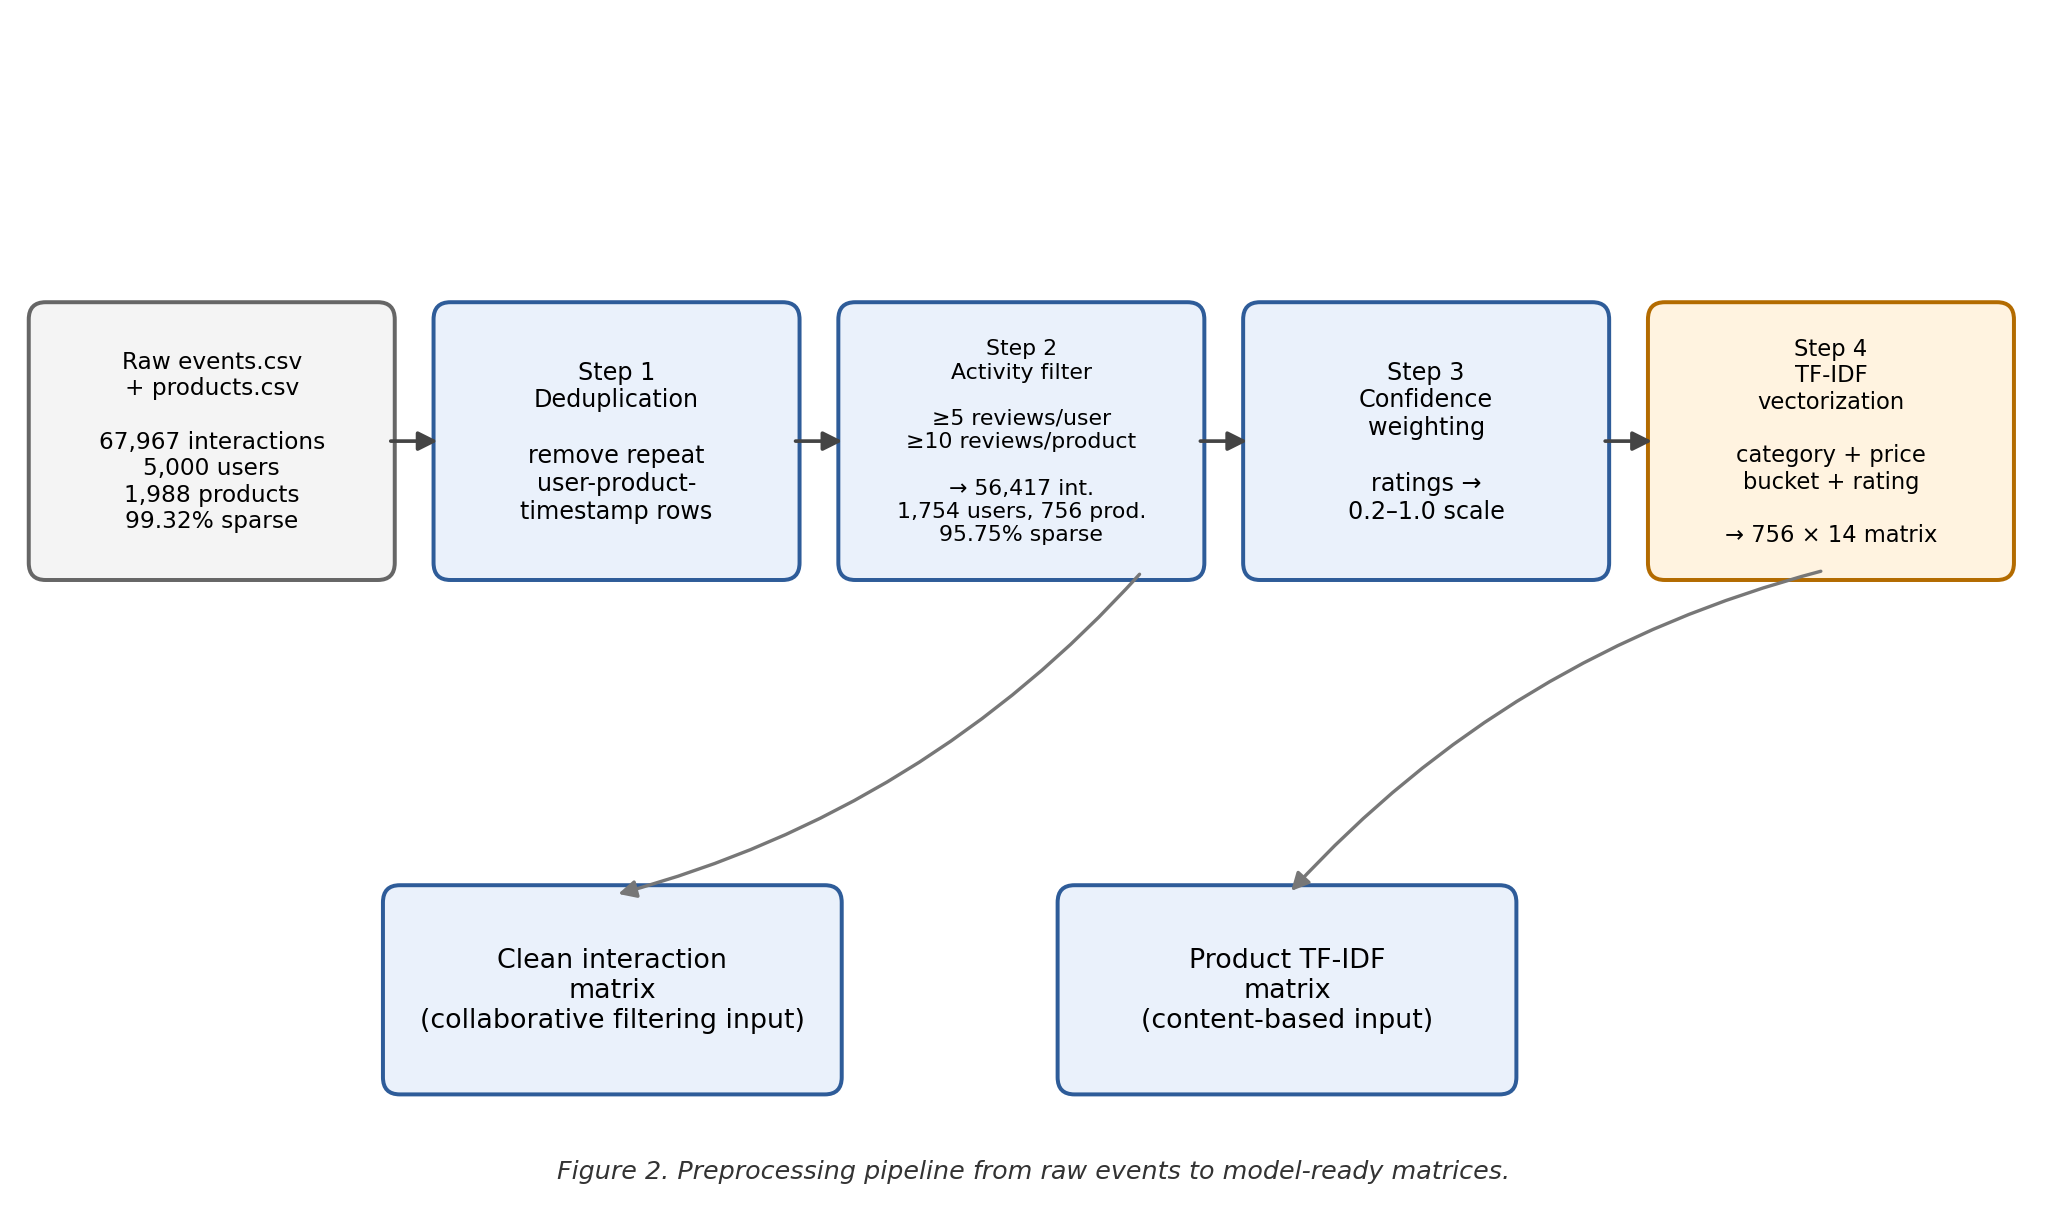

In [2]:
from IPython.display import Image
Image(filename="../images/preprocessing_pipeline.png")

### Validating the sample (activity filter)

The current sample uses minimum activity thresholds rather than a formal stratified sample. This
choice should be checked rather than assumed to preserve the original distribution. The planned
validation compares rating distribution, category mix, and popularity concentration (top-5% share)
between the raw and filtered datasets once the preprocessing rule is finalised. If the long-tail
concentration shifts substantially, the plan is to move to an explicit activity-decile stratified
sample instead of using fixed thresholds alone.

### Data origin

The dataset is generated to match the *broad publicly reported statistical profile* of the McAuley et
al. (2015) Amazon Electronics dataset in terms of sparsity, rating skew, and long-tail concentration,
rather than being resampled from real review text or user records. Full generation parameters and the
generated-versus-target validation comparison are documented in `notes/data-origin.md`, so the process
remains reproducible and auditable. The figure below gives a summary of that comparison for a single
generator run (seed = 42).

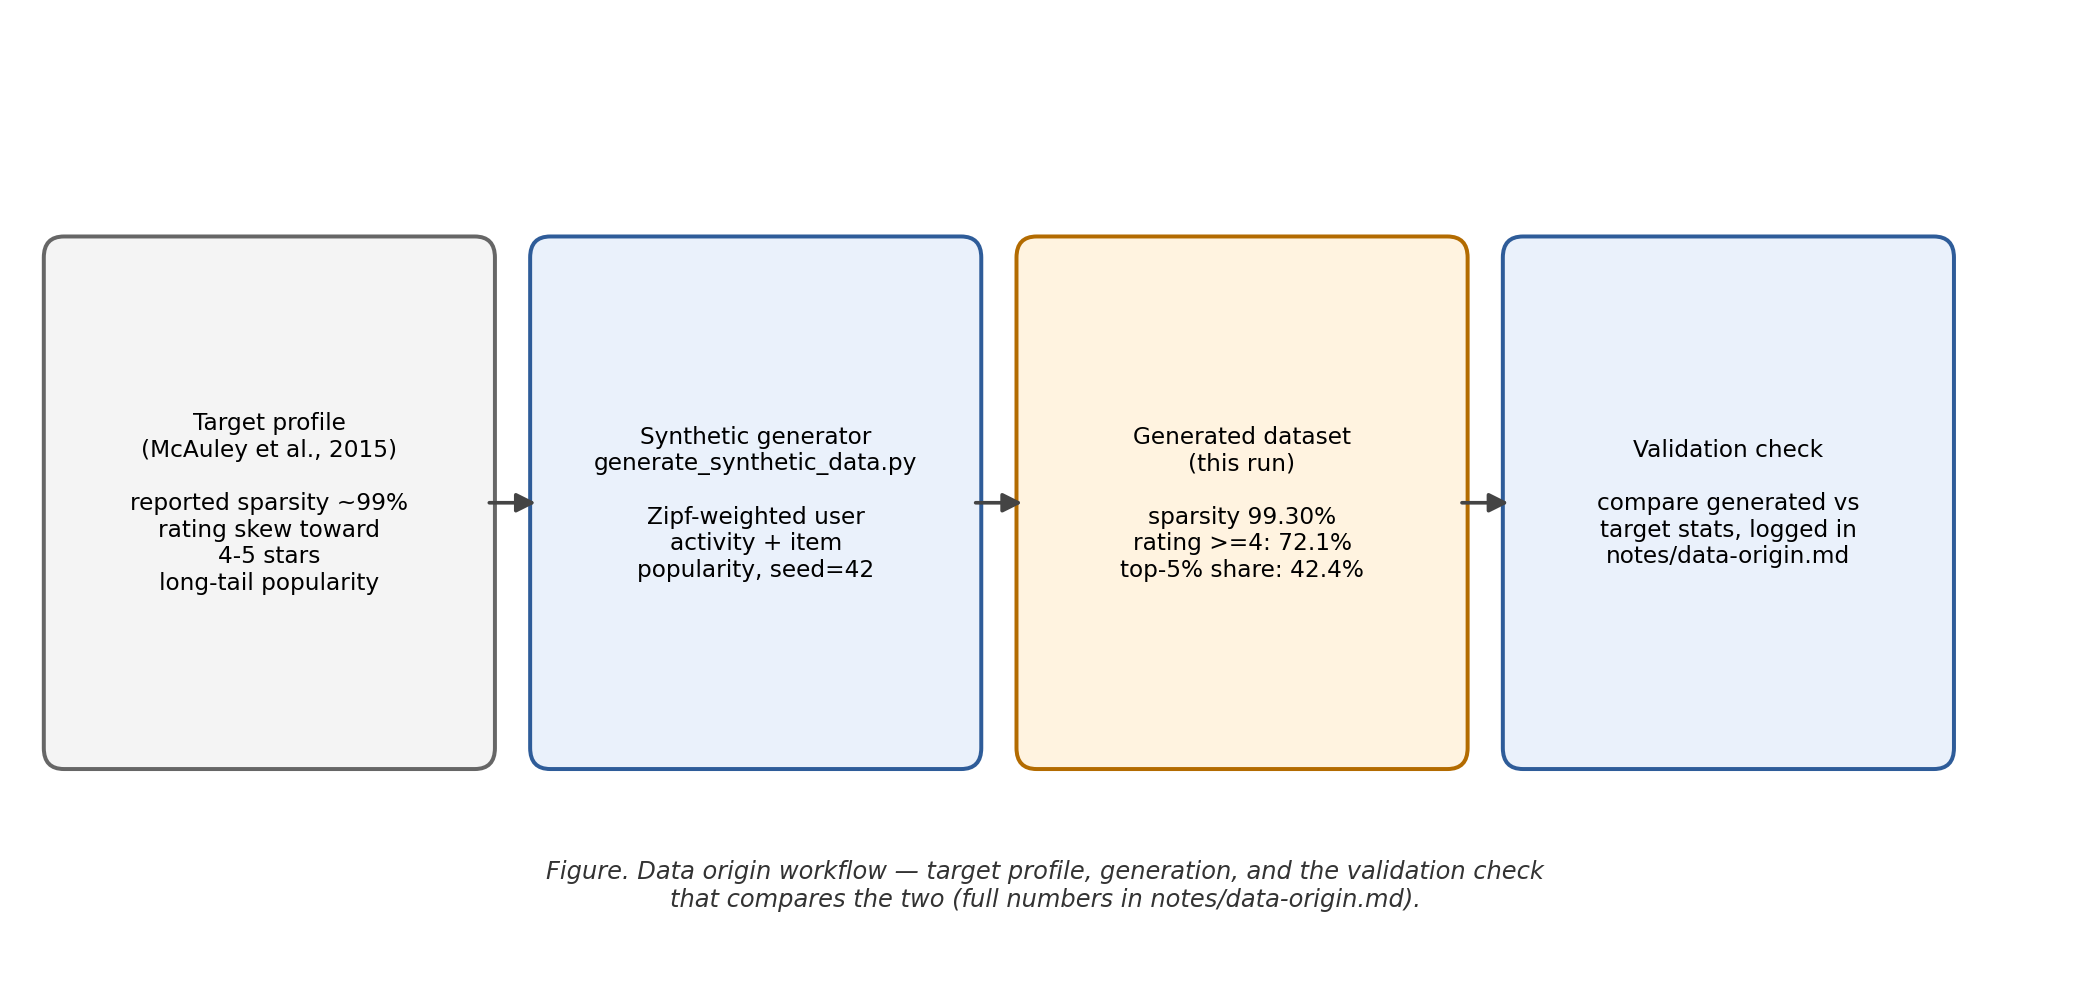

In [3]:
from IPython.display import Image
Image(filename="../images/data_origin_pipeline.png")

## 2. Blueprint for Data Management

Storage is split between `data/raw/` and `data/processed/`, reflecting the usual distinction
between the canonical source data and derived artefacts that can be regenerated by rerunning the
pipeline (Kleppmann, 2017). Version control for the project lives in the Git repository created
during the proposal phase, with commits aligned to milestones rather than accumulated as one final
submission dump. Although the dataset is synthetic, the same discipline is applied to access and
`.gitignore` rules as would be used with real user data.

One storage decision worth noting is that trained model artefacts — including SVD factors, TF-IDF
matrices, and label encoders — are not currently persisted between sessions. They are rebuilt from
scratch each time the pipeline is run. For the current dataset size, this is a reasonable trade-off:
it keeps the repository lightweight and avoids stale artefacts, while still allowing the full
pipeline to be reconstructed deterministically. If the training and evaluation workflow becomes
slower later in the project, this decision may be revisited and artefacts may be cached under
`data/processed/` with an explicit invalidation rule when the raw data changes.

## 3. Model Architecture and Selection

Two models feed into a blending layer:

- **Collaborative filtering** — SVD over the sparse user-item matrix (50 latent factors), stored
  as a SciPy CSR matrix rather than dense. After the stated activity filter, the current matrix has
  2,574 users and 1,666 products, with approximately 1.39% of entries populated (Kleppmann, 2017;
  Koren et al., 2009).
- **Content-based** — cosine similarity over the TF-IDF product vectors (Manning et al., 2008).
  This method does not rely on interaction history and is therefore useful for new users and
  rarely purchased products where collaborative filtering has little information to work with
  (Adomavicius & Tuzhilin, 2005; Burke, 2002).
- **Adaptive blending** — the relative weighting of each model changes according to the amount of
  interaction history a user has, rather than defaulting to a generic popularity list for cold-start
  users (He & McAuley, 2016). This is the key design choice in the project and is therefore stated
  explicitly as:

  **w_cf(n_u) = clip((n_u − n_min) / (n_full − n_min), 0, 1)**, **w_content = 1 − w_cf**

  where n_u is a user's prior interaction count, n_min = 3 and n_full = 20. Below n_min, the
  recommendation is effectively content-based; at or above n_full, it is effectively collaborative
  filtering. These thresholds are starting points for evaluation and can be tuned later, but the
  underlying rule is fixed and reproducible.

The main trade-off in this design is that the latent factor count (k = 50) balances accuracy
against compute cost and overfitting risk. More factors can capture finer patterns, but on a sparse
matrix the signal per factor becomes weaker and the model may begin to fit noise rather than
structure. A value of 50 is a common starting point for datasets of comparable scale rather than a
final tuned choice (Koren et al., 2009). The piecewise-linear blending function is also deliberate:
it uses two named thresholds rather than a more complex curve with an additional tuning parameter.
This makes the model easier to interpret and debug, although it can introduce sharper transitions
around the threshold values than a smoother function would.

### Baselines and success criteria

The adaptive hybrid is intended to be evaluated against three baselines on the same filtered dataset:
**SVD-only**, **TF-IDF-only**, and a **fixed 50/50 hybrid**. The fixed baseline helps isolate whether
the adaptive part contributes anything beyond a simple blend. The design target is that the adaptive
hybrid outperforms the best baseline by at least 5% relative NDCG@10 and shows higher Recall@10 than
the fixed-weight model for cold-start users (n_u < n_min).

### Evaluation methodology

The planned evaluation uses a temporal 80/20 split per user, holding out each user's most recent 20%
of interactions rather than using a random split. Random splits can allow the model to see the future
and therefore overstate performance (McNee et al., 2006). The primary metrics are Precision@10,
Recall@10, NDCG@10, and catalog coverage. Cold-start performance will be assessed separately for
n_u < n_min and n_u >= n_full so it is not hidden within aggregate scores. This is a realistic
evaluation strategy, but it also introduces a limitation: users' most recent interactions may not be
available in training, which could underestimate performance if the system were retrained
continuously in production.

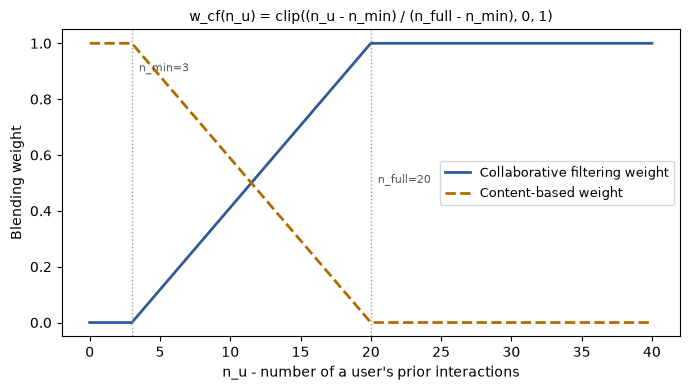

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# plotting the exact formula from the markdown above so the figure and the
# equation can't drift out of sync with each other as the design gets revised
n = np.linspace(0, 40, 400)
n_min, n_full = 3, 20
w_cf = np.clip((n - n_min) / (n_full - n_min), 0, 1)
w_content = 1 - w_cf

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n, w_cf, label="Collaborative filtering weight", color="#2E5C99", linewidth=2)
ax.plot(n, w_content, label="Content-based weight", color="#B36B00", linewidth=2, linestyle="--")
ax.axvline(n_min, color="#999", linewidth=1, linestyle=":")
ax.axvline(n_full, color="#999", linewidth=1, linestyle=":")
ax.text(n_min + 0.5, 0.9, f"n_min={n_min}", fontsize=8, color="#555")
ax.text(n_full + 0.5, 0.5, f"n_full={n_full}", fontsize=8, color="#555")
ax.set_xlabel("n_u - number of a user's prior interactions")
ax.set_ylabel("Blending weight")
ax.legend(fontsize=9)
ax.set_title("w_cf(n_u) = clip((n_u - n_min) / (n_full - n_min), 0, 1)", fontsize=10)
plt.tight_layout()
plt.show()


## 4. Implementation Challenges and Solutions

- **Compute/memory** — everything runs on a personal laptop and free-tier Colab, which is why the
  dataset is sampled rather than full-scale, and why the sparse matrix representation matters.
- **Cold start / long-tail bias** — in the current generated data, the top 5% of products account for
  42.4% of interactions and 72.1% of ratings are 4–5 stars. Confidence weighting addresses the rating
  bias partly; diversity-aware re-ranking is planned as a later step to address the long tail. That
  re-ranking step is its own trade-off: pushing less-popular items higher in the ranked list means some
  purely relevance-ranked items move down, so its strength needs to be assessed against both NDCG and
  catalog coverage rather than optimised for one at the expense of the other (Castells & Moffat, 2022).
- **Evaluation validity** — offline metrics (Precision@K, Recall@K, NDCG@K) only measure whether
  the model reproduces known interactions, not whether a new recommendation is actually good
  (McNee et al., 2006). Catalog coverage is the planned supplement.
- **Scope adjustment** — free-text product descriptions are not included in the current TF-IDF plan;
  the synthetic data does not contain rich enough text fields to make them worthwhile yet.

## References

Adomavicius, G., & Tuzhilin, A. (2005). Toward the next generation of recommender systems: A
survey of the state-of-the-art and possible extensions. *IEEE Transactions on Knowledge and Data
Engineering, 17*(6), 734–749. https://doi.org/10.1109/TKDE.2005.99

Burke, R. (2002). Hybrid recommender systems: Survey and experiments. *User Modeling and
User-Adapted Interaction, 12*(4), 331–370. https://doi.org/10.1023/A:1021240730564

Castells, P., & Moffat, A. (2022). Offline recommender system evaluation: Challenges and new
directions. *AI Magazine, 43*(2), 225–238. https://doi.org/10.1002/aaai.12051

He, R., & McAuley, J. (2016). Ups and downs: Modeling the visual evolution of fashion trends with
one-class collaborative filtering. *Proceedings of the 25th International Conference on World
Wide Web*, 507–517. https://doi.org/10.1145/2872427.2883037

Kleppmann, M. (2017). *Designing data-intensive applications: The big ideas behind reliable,
scalable, and maintainable systems*. O'Reilly Media.

Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix factorization techniques for recommender
systems. *Computer, 42*(8), 30–37. https://doi.org/10.1109/MC.2009.263

Manning, C. D., Raghavan, P., & Schütze, H. (2008). *Introduction to information retrieval*.
Cambridge University Press.

McAuley, J., Targett, C., Shi, Q., & van den Hengel, A. (2015). Image-based recommendations on
styles and substitutes. *Proceedings of the 38th International ACM SIGIR Conference on Research
and Development in Information Retrieval*, 43–52. https://doi.org/10.1145/2766462.2767755

McNee, S. M., Riedl, J., & Konstan, J. A. (2006). Being accurate is not enough: How accuracy
metrics have hurt recommender systems. *CHI '06 Extended Abstracts on Human Factors in Computing
Systems*, 1097–1101. https://doi.org/10.1145/1125451.1125659